In [34]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "../Dataset/Cleaned/online_retail_cleaned.csv",
    dtype={"Invoice": str},
    low_memory=False
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [35]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505193 entries, 0 to 505192
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      505193 non-null  object        
 1   StockCode    505193 non-null  object        
 2   Description  505193 non-null  object        
 3   Quantity     505193 non-null  int64         
 4   InvoiceDate  505193 non-null  datetime64[ns]
 5   Price        505193 non-null  float64       
 6   Customer ID  400947 non-null  float64       
 7   Country      505193 non-null  object        
 8   Revenue      505193 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 34.7+ MB


In [37]:
print("Total Revenue: £{:,.2f}".format(df["Revenue"].sum()))
print("Total Orders:", df["Invoice"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())

Total Revenue: £10,135,584.21
Total Orders: 21003
Total Customers: 4314
Total Products: 4253
Countries: 40


In [38]:
top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries

Country
United Kingdom    8676133.383
EIRE               380909.570
Netherlands        268784.350
Germany            202025.391
France             147103.140
Sweden              53501.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

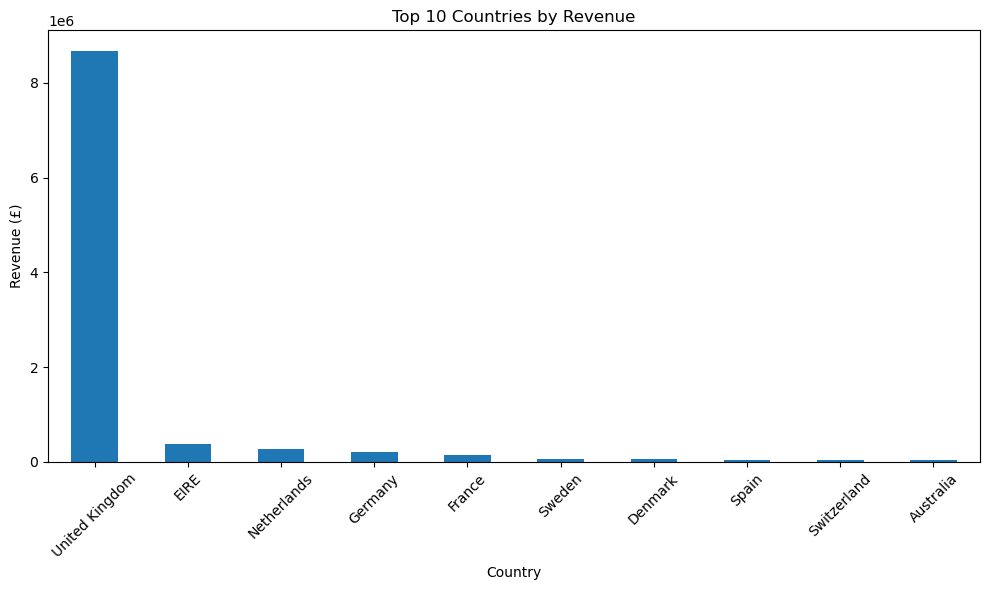

In [39]:
plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
Manual                                 262963.43
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
Name: Revenue, dtype: float64

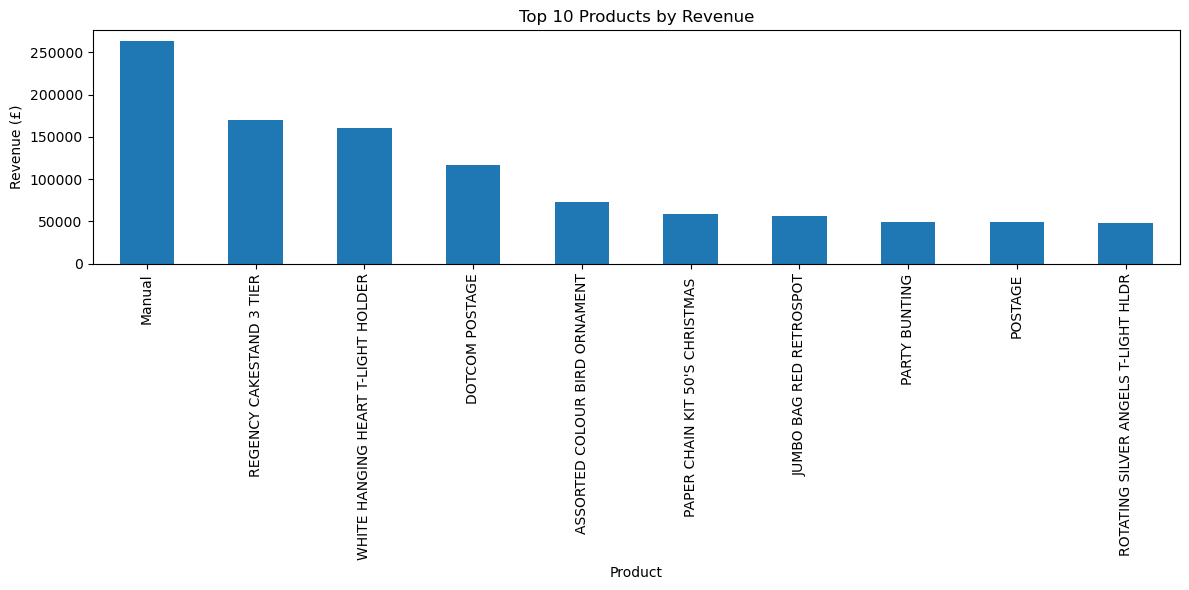

In [41]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")

plt.tight_layout()
plt.show()

In [42]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")

In [43]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales

,Year,Month,Revenue
0,2009,12,822483.950
1,2010,1,651155.112
2,2010,2,551878.296
3,2010,3,830915.261
4,2010,4,625280.892
5,2010,5,657705.500
6,2010,6,749537.310
7,2010,7,604778.480
8,2010,8,695251.910
9,2010,9,921696.991


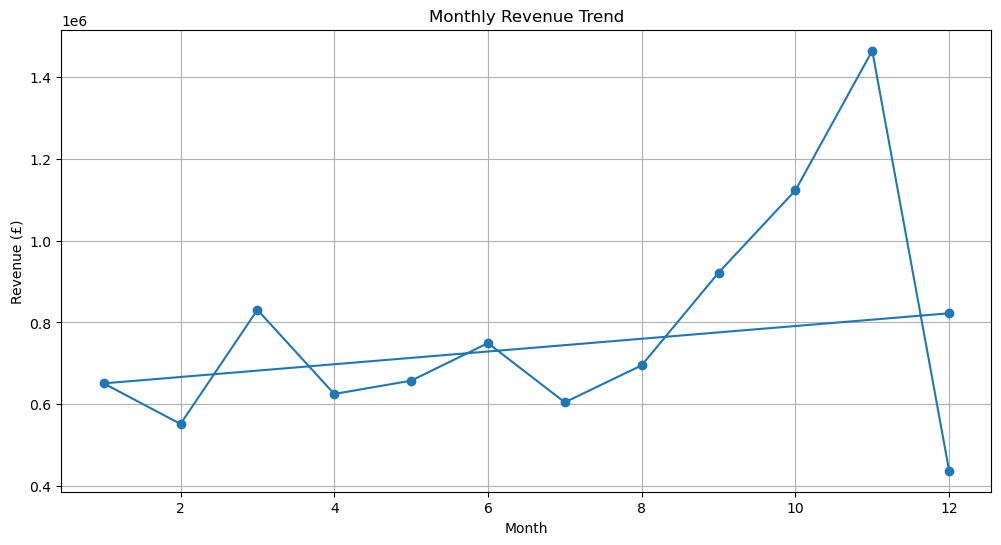

In [44]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales["Month"], monthly_sales["Revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.grid(True)

plt.show()